In [86]:
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , MinMaxScaler


In [45]:
df = pd.read_csv("/content/survey lung cancer.csv")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [46]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [48]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [49]:
df.shape

(309, 16)

In [50]:
df = df.drop_duplicates()

In [51]:
df.shape

(276, 16)

In [52]:
df['GENDER'].unique()

array(['M', 'F'], dtype=object)

In [53]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [54]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
gender_encoded = encoder.fit_transform(df[['GENDER']])
gender_df = pd.DataFrame(gender_encoded, columns=encoder.get_feature_names_out(['GENDER']))
df = pd.concat([df.reset_index(drop=True), gender_df], axis=1)
df = df.drop('GENDER', axis=1)

In [55]:
df.head()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,GENDER_F,GENDER_M
0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES,0.0,1.0
1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES,0.0,1.0
2,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO,1.0,0.0
3,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO,0.0,1.0
4,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO,1.0,0.0


In [56]:
LEncode = LabelEncoder()
df['LUNG_CANCER'] = LEncode.fit_transform(df['LUNG_CANCER'])

In [57]:
df.head()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,GENDER_F,GENDER_M
0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1,0.0,1.0
1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1,0.0,1.0
2,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0,1.0,0.0
3,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0,0.0,1.0
4,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0,1.0,0.0


Text(0.5, 1.0, 'Correlation Heatmap')

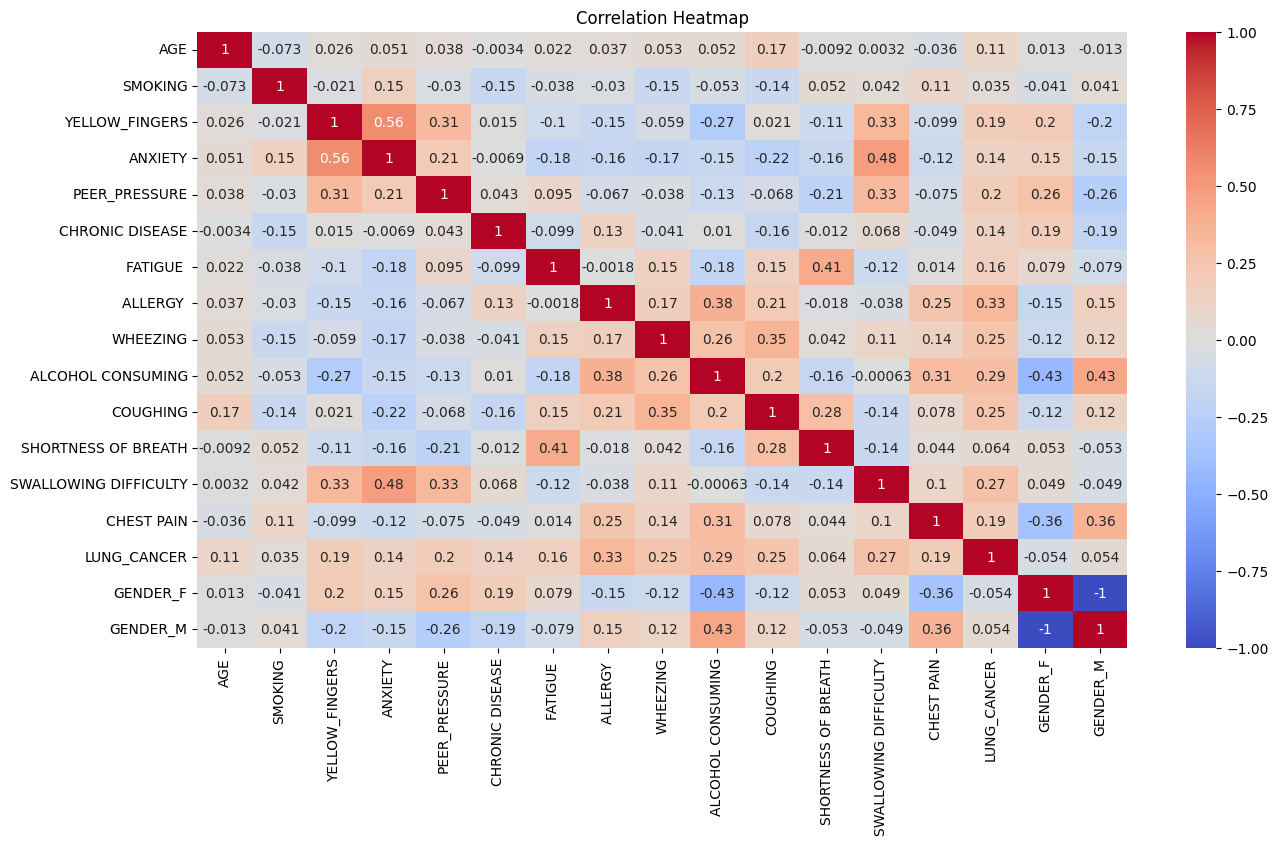

In [58]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

In [59]:
y.value_counts()

,count
LUNG_CANCER,
1,238
0,38


In [66]:
features = [
    'ALLERGY ', 'ALCOHOL CONSUMING', 'SWALLOWING DIFFICULTY',
    'WHEEZING', 'COUGHING', 'PEER_PRESSURE', 'YELLOW_FINGERS',
    'ANXIETY', 'CHRONIC DISEASE', 'FATIGUE '
]

In [67]:
x = df[features]
y = df['LUNG_CANCER']

In [68]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [94]:
scale = MinMaxScaler()
# X_train_scaled=scale.fit_transform(x_train)
# X_test_scaled=scale.transform(x_test)

x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [95]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print(f"Original Training Count: {y_train.value_counts().to_dict()}")
print(f"New SMOTE Count: {y_train_resampled.value_counts().to_dict()}")

Original Training Count: {1: 194, 0: 26}
New SMOTE Count: {1: 194, 0: 194}


In [96]:
model = BernoulliNB()
model.fit(X_train_resampled, y_train_resampled)

BernoulliNB()

In [97]:
y_pred = model.predict(x_test)

In [98]:
#accuracy calculation

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cp = classification_report(y_test, y_pred)

Accuracy: 0.875


In [99]:
print(classification_report(y_test, y_pred, target_names=LEncode.classes_))

              precision    recall  f1-score   support

          NO       0.65      0.92      0.76        12
         YES       0.97      0.86      0.92        44

    accuracy                           0.88        56
   macro avg       0.81      0.89      0.84        56
weighted avg       0.90      0.88      0.88        56

